# Демонстрации к лекции 4: стационарные точки, градиентный спуск и число обусловленности

Ноутбук — для самостоятельной проверки после пары: всё, что на лекции было формулой или картинкой, здесь считается кодом, а числа из конспекта воспроизводятся. Читается сверху вниз; каждая часть начинается с «что проверяем и что должны увидеть». Разминка и пять частей:

- **(0)** три задачи-крючка (раздел 1 конспекта): Розенброк, цепь без пола из лекции 1, логистическая регрессия — во всех трёх ограничений нет;
- **(a)** стационарные точки и гессиан (разделы 2–3): три стационарные точки $(x_1^2-1)^2+x_2^2$, седло против минимума по собственным числам; гессиан Розенброка в $(1,1)$ и его $\kappa$;
- **(b)** градиентный спуск на квадратичной (разделы 4–5): точный и постоянный шаг, число итераций против $\kappa$, множители сжатия $((\kappa-1)/(\kappa+1))^2$ и $1-1/\kappa$, перебор шага и граница $2/L$, зигзаг;
- **(c)** Розенброк: GD против Ньютона (разделы 5–7): 13 756 итераций против 7, линейная сходимость против квадратичной;
- **(d)** логистическая регрессия и масштабирование признаков (раздел 5): $\kappa\approx7.5\cdot10^4$ без стандартизации и $\approx2.75$ с ней;
- **(e)** цепь: $\kappa$ растёт с числом грузов как $N^2$ (раздел 5, упражнение 12.9), и почему Ньютон здесь — это `np.linalg.solve`.

Конспект: [`lecture04.md`](lecture04.md). Запуск: `uv run jupyter lab` в корне репозитория. Пакеты — только `numpy`, `scipy`, `matplotlib`.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root

BLUE, ORANGE, AQUA, RED, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#8a8985", "#0b0b0b"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "legend.frameon": False})
rng = np.random.default_rng(4)


def gd(f, grad, x0, alpha=None, tol=1e-6, maxit=100_000, c=1e-4):
    """Градиентный спуск. alpha=None — backtracking: начинаем с 1, делим пополам, пока не
    выполнено условие Армихо с константой c. Иначе — постоянный шаг alpha.
    Возвращает (x, число итераций, путь как массив (k+1, n))."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        if alpha is None:
            a, fx = 1.0, f(x)
            while f(x - a * g) > fx - c * a * (g @ g):
                a /= 2
        else:
            a = alpha
        x = x - a * g; path.append(x.copy())
    return x, maxit, np.array(path)


def newton(grad, hess, x0, tol=1e-10, maxit=50):
    """Чистый метод Ньютона без линейного поиска. Возвращает (x, число итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = grad(x)
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        x = x - np.linalg.solve(hess(x), g); path.append(x.copy())
    return x, maxit, np.array(path)

## (0) Три задачи-крючка

Раздел 1 конспекта. Три задачи из прошлых лекций, у которых **нет ограничений**: ни равенств, ни неравенств, ни ящика — минимизируем по всему $\mathbb R^n$. В лекциях 1–3 мы решали их солвером «как чёрным ящиком»; сегодня разбираем, что внутри. Здесь только определяем функции, градиенты и гессианы и смотрим на данные — считать будем в частях (a)–(e).

**Задача А. Функция Розенброка** $f(x)=(1-x_1)^2+100\,(x_2-x_1^2)^2$. Минимум $f=0$ в $(1,1)$, лежит на дне узкой изогнутой долины $x_2=x_1^2$. Линии уровня — в логарифмическом масштабе, иначе долину не видно.

f(1,1) = 0.0   grad f(1,1) = [-0.  0.]
старт (-1.2, 1): f = 24.2  |grad f| = 232.87


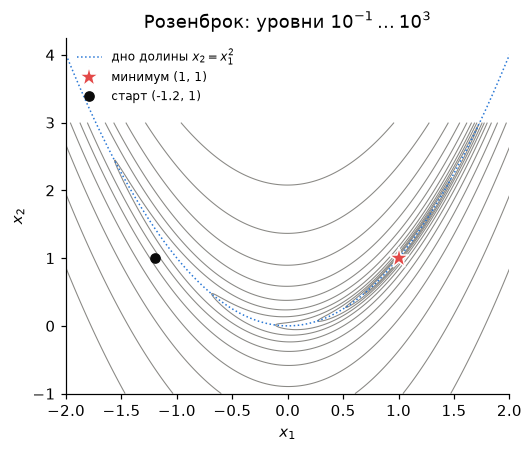

In [2]:
rosen = lambda x: (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2
rosen_grad = lambda x: np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2), 200 * (x[1] - x[0]**2)])
rosen_hess = lambda x: np.array([[2 - 400 * x[1] + 1200 * x[0]**2, -400 * x[0]], [-400 * x[0], 200]])

x_star = np.array([1.0, 1.0])
print("f(1,1) =", rosen(x_star), "  grad f(1,1) =", rosen_grad(x_star))
print("старт (-1.2, 1): f =", round(rosen(np.array([-1.2, 1.0])), 3), " |grad f| =", np.linalg.norm(rosen_grad(np.array([-1.2, 1.0]))).round(2))

xs, ys = np.linspace(-2, 2, 400), np.linspace(-1, 3, 400)
X1, X2 = np.meshgrid(xs, ys)
F_rosen = (1 - X1)**2 + 100 * (X2 - X1**2)**2

fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.contour(X1, X2, F_rosen, levels=np.logspace(-1, 3, 12), colors=[GRAY], linewidths=0.7)
ax.plot(xs, xs**2, ls=":", color=BLUE, lw=1, label="дно долины $x_2=x_1^2$")
ax.plot(1, 1, "*", ms=14, color=RED, mec="white", label="минимум (1, 1)")
ax.plot(-1.2, 1, "o", color=INK, label="старт (-1.2, 1)")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Розенброк: уровни $10^{-1}\dots10^{3}$"); ax.legend(loc="upper left", fontsize=8); ax.grid(False)
plt.show()

**Задача Б. Цепь без пола** (лекция 1, §7.3). $N$ грузов массой $m=4/N$ на пружинах жёсткости $D=70$ между креплениями $(-2,1)$ и $(2,1)$; переменные $v=(y_1..y_N,\,z_1..z_N)$, энергия $E(v)=\tfrac D2\sum_i\big((y_{i+1}-y_i)^2+(z_{i+1}-z_i)^2\big)+mg\sum_i z_i$. Энергия **квадратичная**: градиент линеен по $v$, гессиан постоянен — $\nabla^2E=\operatorname{diag}(DK,\,DK)$ с трёхдиагональной $K$ ($2$ на диагонали, $-1$ рядом). Значит минимум — решение линейной системы $\nabla^2E\,v=-\nabla E(0)$. Проверяем, что собранная матрица действительно гессиан: $\nabla E(v)-\nabla E(0)=Hv$ для случайного $v$.

проверка гессиана: max |grad E(v) - grad E(0) - H v| = 0.0
энергия на старте (прямая): 52.8985,  в минимуме: 13.4417,  |grad E| в минимуме: 9.0e-14


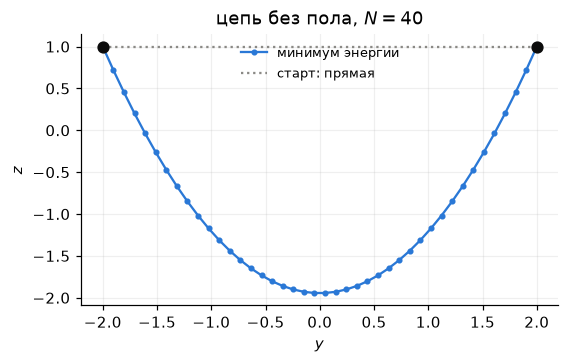

In [3]:
D_CHAIN, G_CHAIN = 70.0, 9.81
p_left, p_right = np.array([-2.0, 1.0]), np.array([2.0, 1.0])


def make_chain(N):
    """Энергия, градиент, гессиан и стартовая точка (прямая между концами) для цепи из N грузов."""
    m = 4.0 / N

    def unpack(v):
        return np.r_[p_left[0], v[:N], p_right[0]], np.r_[p_left[1], v[N:], p_right[1]]

    def energy(v):
        y, z = unpack(v)
        return 0.5 * D_CHAIN * np.sum(np.diff(y)**2 + np.diff(z)**2) + m * G_CHAIN * np.sum(z[1:-1])

    def grad_E(v):
        y, z = unpack(v)
        return np.r_[D_CHAIN * (2 * y[1:-1] - y[:-2] - y[2:]), D_CHAIN * (2 * z[1:-1] - z[:-2] - z[2:]) + m * G_CHAIN]

    K = 2 * np.eye(N) - np.eye(N, k=1) - np.eye(N, k=-1)
    H = np.kron(np.eye(2), D_CHAIN * K)
    v0 = np.r_[np.linspace(p_left[0], p_right[0], N + 2)[1:-1], np.linspace(p_left[1], p_right[1], N + 2)[1:-1]]
    return energy, grad_E, unpack, K, H, v0


N = 40
energy, grad_E, unpack, K, H, v0 = make_chain(N)
v_test = rng.normal(size=2 * N)
print("проверка гессиана: max |grad E(v) - grad E(0) - H v| =", np.abs(grad_E(v_test) - grad_E(np.zeros(2 * N)) - H @ v_test).max().round(12))

v_chain = np.linalg.solve(H, -grad_E(np.zeros(2 * N)))
print(f"энергия на старте (прямая): {energy(v0):.4f},  в минимуме: {energy(v_chain):.4f},  |grad E| в минимуме: {np.linalg.norm(grad_E(v_chain)):.1e}")

y, z = unpack(v_chain)
plt.figure(figsize=(5.6, 3.2))
plt.plot(y, z, "-o", ms=3, color=BLUE, label="минимум энергии")
plt.plot(*unpack(v0), ls=":", color=GRAY, label="старт: прямая")
plt.plot([-2, 2], [1, 1], "o", color=INK, ms=7)
plt.xlabel("$y$"); plt.ylabel("$z$"); plt.legend(loc="upper center", fontsize=8.5); plt.title(f"цепь без пола, $N={N}$")
plt.show()

**Задача В. Логистическая регрессия** (лекция 1, §7.5). Синтетические данные: $n=200$ человек, признаки — возраст (лет) и стаж (лет), класс $y\in\{0,1\}$ разыгрывается с вероятностью $\sigma(1.5z_1-z_2+0.3)$ по стандартизованным $z$. Модель: $\Pr(y=1\mid x)=\sigma(w^\top x)$, $x=(1,\text{возраст},\text{стаж})$; цель $f(w)=\frac1n\sum_i\log\big(1+e^{-\tilde y_i\,x_i^\top w}\big)$, $\tilde y_i=2y_i-1\in\{-1,1\}$ — гладкая, выпуклая, без ограничений. Обратите внимание на масштабы признаков: возраст разбросан на $\pm10$, стаж — на $\pm1$. Это выстрелит в части (d).

объектов: 200, класс 1: 119, класс 0: 81
возраст: среднее 40.5, std 10.0;   стаж: среднее 5.02, std 1.02


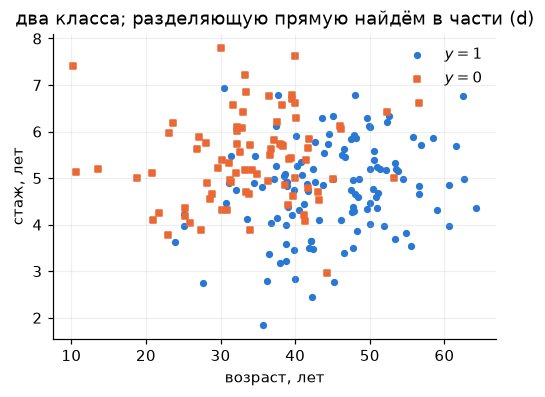

In [4]:
rng = np.random.default_rng(4)          # заново, чтобы ячейку можно было перезапускать: данные должны быть теми же
n = 200
z1, z2 = rng.normal(0, 1, n), rng.normal(0, 1, n)
p_true = 1 / (1 + np.exp(-(1.5 * z1 - 1.0 * z2 + 0.3)))
y_cls = (rng.uniform(size=n) < p_true).astype(float)
age, exper = 40 + 10 * z1, 5 + z2
X = np.c_[np.ones(n), age, exper]

print(f"объектов: {n}, класс 1: {int(y_cls.sum())}, класс 0: {int(n - y_cls.sum())}")
print(f"возраст: среднее {age.mean():.1f}, std {age.std():.1f};   стаж: среднее {exper.mean():.2f}, std {exper.std():.2f}")

plt.figure(figsize=(5.2, 3.6))
plt.scatter(age[y_cls == 1], exper[y_cls == 1], s=14, color=BLUE, label="$y=1$")
plt.scatter(age[y_cls == 0], exper[y_cls == 0], s=14, color=ORANGE, marker="s", label="$y=0$")
plt.xlabel("возраст, лет"); plt.ylabel("стаж, лет"); plt.legend(); plt.title("два класса; разделяющую прямую найдём в части (d)")
plt.show()

Итак: три задачи, ни одного ограничения, все три — **безусловные** ($\min_{x\in\mathbb R^n}f(x)$). Розенброк — гладкая, невыпуклая, с одной стационарной точкой; цепь — квадратичная и выпуклая; логистическая регрессия — выпуклая, но не квадратичная. Все три решаем сегодня, и на всех трёх увидим одно и то же: скорость градиентного спуска диктует число обусловленности гессиана.

## (a) Стационарные точки и гессиан

Разделы 2–3 конспекта, упражнение 12.1. Пример из лекции 2: $f(x)=(x_1^2-1)^2+x_2^2$, $\nabla f=(4x_1(x_1^2-1),\,2x_2)$. Условие первого порядка $\nabla f=0$ даёт три точки: $(0,0)$ и $(\pm1,0)$. Гессиан $\nabla^2f=\operatorname{diag}(12x_1^2-4,\,2)$ — смотрим на его собственные числа: все положительны — строгий минимум, есть отрицательное — седло (не минимум). На картинке — поле $-\nabla f$ (куда пойдёт градиентный спуск): к минимумам стрелки сходятся, от седла вдоль $x_1$ — расходятся.

точка [0. 0.]: |grad f| = 0e+00,  собственные числа гессиана [-4.  2.]  ->  седло, f = 1
точка [1. 0.]: |grad f| = 0e+00,  собственные числа гессиана [2. 8.]  ->  строгий минимум, f = 0
точка [-1.  0.]: |grad f| = 0e+00,  собственные числа гессиана [2. 8.]  ->  строгий минимум, f = 0
GD из [0.0, 0.5]: пришёл в [0. 0.] за 1 итераций
GD из [0.01, 0.5]: пришёл в [1. 0.] за 16 итераций


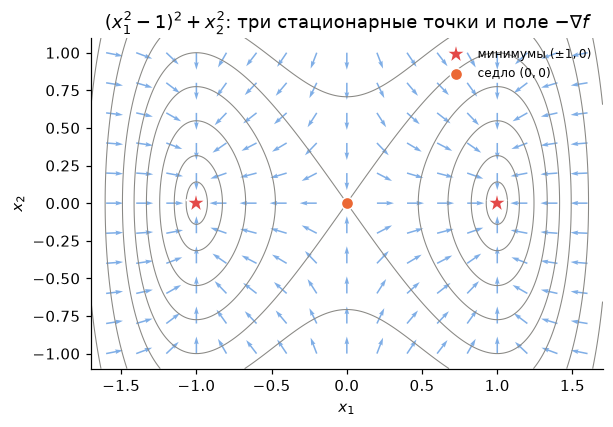

In [5]:
f_a = lambda x: (x[0]**2 - 1)**2 + x[1]**2
grad_a = lambda x: np.array([4 * x[0] * (x[0]**2 - 1), 2 * x[1]])
hess_a = lambda x: np.diag([12 * x[0]**2 - 4, 2.0])

for pt in ([0.0, 0.0], [1.0, 0.0], [-1.0, 0.0]):
    pt = np.array(pt); lam = np.linalg.eigvalsh(hess_a(pt))
    kind = "строгий минимум" if lam.min() > 0 else ("седло" if lam.min() < 0 < lam.max() else "максимум")
    print(f"точка {pt}: |grad f| = {np.linalg.norm(grad_a(pt)):.0e},  собственные числа гессиана {lam}  ->  {kind}, f = {f_a(pt):.0f}")

# упражнение 12.1: куда придёт градиентный спуск из (0, 0.5) и из (0.01, 0.5)?
for x0 in ([0.0, 0.5], [0.01, 0.5]):
    x, k, _ = gd(f_a, grad_a, x0)
    print(f"GD из {x0}: пришёл в {x.round(6)} за {k} итераций")

xs = np.linspace(-1.7, 1.7, 300); ys = np.linspace(-1.1, 1.1, 300)
X1, X2 = np.meshgrid(xs, ys)
Fa = (X1**2 - 1)**2 + X2**2
qx, qy = np.meshgrid(np.arange(-1.6, 1.61, 0.2), np.arange(-1.0, 1.01, 0.2))
U, V = -4 * qx * (qx**2 - 1), -2 * qy
nrm = np.hypot(U, V) + 1e-12
fig, ax = plt.subplots(figsize=(6, 4))
ax.contour(X1, X2, Fa, levels=[0.02, 0.1, 0.3, 0.6, 1, 1.5, 2.5, 4], colors=[GRAY], linewidths=0.7)
ax.quiver(qx, qy, U / nrm, V / nrm, color=BLUE, alpha=0.6, scale=30, width=0.003)
ax.plot([1, -1], [0, 0], "*", ms=14, color=RED, mec="white", ls="none", label="минимумы $(\pm1,0)$")
ax.plot(0, 0, "o", ms=8, color=ORANGE, mec="white", label="седло $(0,0)$")
ax.set(aspect="equal", xlabel="$x_1$", ylabel="$x_2$", title="$(x_1^2-1)^2+x_2^2$: три стационарные точки и поле $-\\nabla f$"); ax.legend(loc="upper right", fontsize=8); ax.grid(False)
plt.show()

Из $(0,0.5)$ спуск пришёл в **седло**: первая компонента градиента там тождественно нуль, $x_1$ так и остаётся нулём, и метод честно нашёл стационарную точку, а не минимум. Сдвиг старта на $0.01$ всё меняет: $x_1$ растёт, и приходим в $(1,0)$. Мораль раздела 2: градиентный спуск гарантирует только $\nabla f=0$; к седлу он сходится лишь со множества меры нуль.

**Розенброк.** Гессиан в $(1,1)$ равен $\begin{pmatrix}802&-400\\-400&200\end{pmatrix}$; должны увидеть собственные числа $0.3994$ и $1001.6$ — оба положительны (минимум), но отличаются в $\kappa\approx2508$ раз. Что $(1,1)$ — единственная стационарная точка, видно руками: из второго уравнения $200(x_2-x_1^2)=0$ следует $x_2=x_1^2$, тогда первое даёт $-2(1-x_1)=0$. Численная проверка — `scipy.optimize.root` для системы $\nabla f=0$ из случайных стартов: все сошедшиеся запуски приходят в $(1,1)$. Часть стартов у `root` «застревает» — это первый звонок из части (c): решать $\nabla f=0$ ньютоновским методом вдали от решения ненадёжно.

In [6]:
H1 = rosen_hess(np.array([1.0, 1.0]))
lam = np.linalg.eigvalsh(H1)
print("гессиан в (1,1):\n", H1)
print(f"собственные числа: {lam[0]:.4f} и {lam[1]:.1f};  κ = {lam[1] / lam[0]:.1f}")

starts = rng.uniform(-3, 3, size=(20, 2))
sols = [root(rosen_grad, s, jac=rosen_hess) for s in starts]
ok = np.array([r.x for r in sols if r.success])
stuck = np.array([np.linalg.norm(rosen_grad(r.x)) for r in sols if not r.success])
print(f"root сошёлся из {len(ok)} стартов из {len(starts)}; найденные решения (уникальные):", np.unique(ok.round(6), axis=0))
print(f"остальные {len(stuck)} запусков застряли там, где |grad f| = {stuck.min():.2f} .. {stuck.max():.2f} — это не стационарные точки")

гессиан в (1,1):
 [[ 802. -400.]
 [-400.  200.]]
собственные числа: 0.3994 и 1001.6;  κ = 2508.0
root сошёлся из 14 стартов из 20; найденные решения (уникальные): [[1. 1.]]
остальные 6 запусков застряли там, где |grad f| = 0.02 .. 1.75 — это не стационарные точки


$\kappa=2508$ — это «длина долины к её ширине». Часть (b) покажет, что это число — сколько итераций спуска нужно на одну верную цифру.

## (b) Градиентный спуск на квадратичной

Разделы 4–5 конспекта, упражнение 12.3. Функция $f(x)=\tfrac12(x_1^2+\kappa x_2^2)=\tfrac12x^\top Qx$, $Q=\operatorname{diag}(1,\kappa)$; $\lambda_{\min}=1$, $\lambda_{\max}=\kappa$, минимум в нуле, ошибка $e_k=x_k$. Старт $(\kappa,1)$ — «худший» для спуска, останов по $\|\nabla f\|\le10^{-8}$.

**Точный шаг** $\alpha_k=\dfrac{g^\top g}{g^\top Qg}$ (минимум $f$ вдоль $-g$ считается в одну строку, потому что $f$ квадратичная). Теория: $f(x_{k+1})\le\big(\tfrac{\kappa-1}{\kappa+1}\big)^2f(x_k)$. Должны увидеть: для $\kappa=2$ — 18 итераций и множитель $1/9$, для $\kappa=50$ — 567 итераций и множитель $0.923$; отношение $f_{k+1}/f_k$ на этой траектории совпадает с оценкой точно.

In [7]:
def gd_exact(Q, x0, tol=1e-8, maxit=100_000):
    """Градиентный спуск с точным линейным поиском на f = 1/2 x^T Q x. Возвращает (x, число итераций, путь)."""
    x = np.asarray(x0, float).copy(); path = [x.copy()]
    for k in range(maxit):
        g = Q @ x
        if np.linalg.norm(g) <= tol:
            return x, k, np.array(path)
        a = (g @ g) / (g @ Q @ g)
        x = x - a * g; path.append(x.copy())
    return x, maxit, np.array(path)


paths_exact = {}
for kappa in (2, 50):
    Q = np.diag([1.0, float(kappa)])
    x, k, path = gd_exact(Q, (kappa, 1))
    fs = 0.5 * np.einsum("ki,ij,kj->k", path, Q, path)
    ratio = fs[1:] / fs[:-1]
    paths_exact[kappa] = path
    print(f"κ = {kappa:2d}: итераций {k:4d};  f_(k+1)/f_k = {np.median(ratio):.4f} (мин {ratio.min():.4f}, макс {ratio.max():.4f});  теория ((κ-1)/(κ+1))^2 = {((kappa - 1) / (kappa + 1))**2:.4f}")

κ =  2: итераций   18;  f_(k+1)/f_k = 0.1111 (мин 0.1111, макс 0.1111);  теория ((κ-1)/(κ+1))^2 = 0.1111
κ = 50: итераций  567;  f_(k+1)/f_k = 0.9231 (мин 0.9231, макс 0.9231);  теория ((κ-1)/(κ+1))^2 = 0.9231


**Постоянный шаг** $\alpha=1/\lambda_{\max}=1/\kappa$ — тот, что гарантирует лемма о спуске (раздел 4). Покоординатно $x_1\leftarrow(1-1/\kappa)x_1$, $x_2\leftarrow0$: после первой итерации вся ошибка сидит в $x_1$ и сжимается ровно в $1-1/\kappa$ за шаг. Должны увидеть 28 и 1106 итераций, множители $0.5$ и $0.98$; при $\kappa=50$ на одну верную цифру уходит $\ln10/(-\ln0.98)\approx114$ итераций.

In [8]:
paths_const = {}
for kappa in (2, 50):
    Q = np.diag([1.0, float(kappa)])
    f_q, grad_q = (lambda x, Q=Q: 0.5 * x @ Q @ x), (lambda x, Q=Q: Q @ x)
    x, k, path = gd(f_q, grad_q, (kappa, 1), alpha=1 / kappa, tol=1e-8)
    err = np.linalg.norm(path, axis=1)
    paths_const[kappa] = path
    print(f"κ = {kappa:2d}: итераций {k:4d};  |e_(k+1)|/|e_k| = {err[-1] / err[-2]:.4f};  теория 1 - 1/κ = {1 - 1 / kappa:.4f};"
          f"  итераций на одну верную цифру: {np.log(10) / -np.log(1 - 1 / kappa):.0f}")

κ =  2: итераций   28;  |e_(k+1)|/|e_k| = 0.5000;  теория 1 - 1/κ = 0.5000;  итераций на одну верную цифру: 3
κ = 50: итераций 1106;  |e_(k+1)|/|e_k| = 0.9800;  теория 1 - 1/κ = 0.9800;  итераций на одну верную цифру: 114


**Перебор шага** при $\kappa=50$. Метод сходится тогда и только тогда, когда $|1-\alpha|<1$ и $|1-\alpha\kappa|<1$, то есть при $0<\alpha<2/\lambda_{\max}=0.04$; лучший шаг уравнивает два множителя: $\alpha=2/(\kappa+1)=2/51\approx0.0392$, множитель $(\kappa-1)/(\kappa+1)=0.961$ — примерно 58 итераций на цифру вместо 114. Шаг $0.041>2/\lambda_{\max}$ должен расходиться: норма $x_k$ растёт как $|1-0.041\cdot50|^k=1.05^k$. Ограничиваем `maxit=2000` и печатаем норму.

In [9]:
kappa = 50
Q = np.diag([1.0, float(kappa)])
f_q, grad_q = (lambda x: 0.5 * x @ Q @ x), (lambda x: Q @ x)
print(f"граница устойчивости 2/λ_max = {2 / kappa:.4f},  лучший постоянный шаг 2/(κ+1) = {2 / (kappa + 1):.4f}\n")
for a, label in ((0.02, "1/κ"), (0.039, ""), (2 / (kappa + 1), "2/(κ+1), лучший"), (0.041, "> 2/λ_max")):
    with np.errstate(over="ignore", invalid="ignore"):
        x, k, path = gd(f_q, grad_q, (kappa, 1), alpha=a, tol=1e-8, maxit=2000)
    status = f"сошёлся за {k} итераций" if k < 2000 else f"НЕ сошёлся за 2000 итераций, |x_k| = {np.linalg.norm(x):.1e}"
    print(f"α = {a:.4f} {label:16s}: {status}")

граница устойчивости 2/λ_max = 0.0400,  лучший постоянный шаг 2/(κ+1) = 0.0392

α = 0.0200 1/κ             : сошёлся за 1106 итераций
α = 0.0390                 : сошёлся за 562 итераций
α = 0.0392 2/(κ+1), лучший : сошёлся за 567 итераций
α = 0.0410 > 2/λ_max       : НЕ сошёлся за 2000 итераций, |x_k| = 2.4e+42


**Зигзаг.** Первые 15 итераций на линиях уровня (эллипсы с полуосями $1:\sqrt\kappa$). При точном шаге соседние градиенты ортогональны (упражнение 12.8в), и путь «отскакивает» от стенок долины; при $\kappa=50$ шаги видны только у самого дна. Постоянный шаг $1/\kappa$ пунктиром: после первого шага $x_2=0$, дальше метод ползёт вдоль дна.

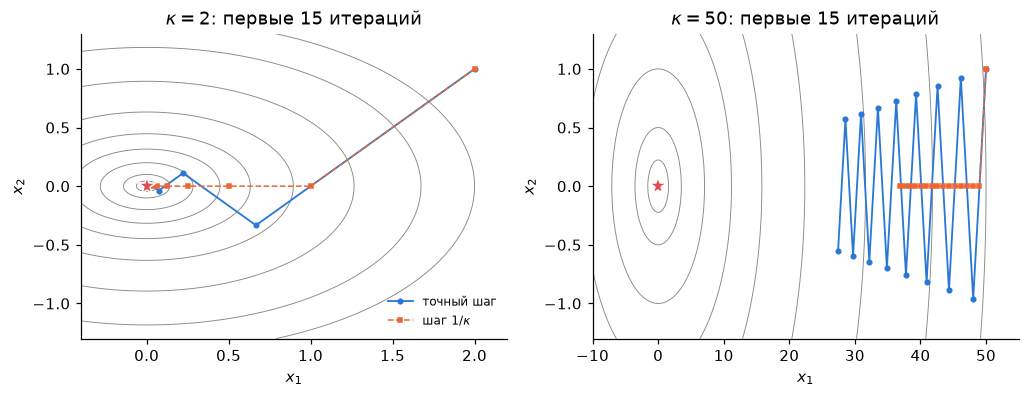

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, kappa in zip(axes, (2, 50)):
    pe, pc = paths_exact[kappa][:16], paths_const[kappa][:16]
    xs = np.linspace(-0.2 * kappa, 1.1 * kappa, 300); ys = np.linspace(-1.3, 1.3, 300)
    X1, X2 = np.meshgrid(xs, ys)
    Fq = 0.5 * (X1**2 + kappa * X2**2)
    ax.contour(X1, X2, Fq, levels=0.5 * kappa**2 * np.array([0.001, 0.005, 0.02, 0.05, 0.1, 0.2, 0.4, 0.7, 1.0]), colors=[GRAY], linewidths=0.6)
    ax.plot(pe[:, 0], pe[:, 1], "-o", ms=3, lw=1.2, color=BLUE, label="точный шаг")
    ax.plot(pc[:, 0], pc[:, 1], "--s", ms=3, lw=1.0, color=ORANGE, label="шаг $1/\\kappa$")
    ax.plot(0, 0, "*", ms=12, color=RED, mec="white")
    ax.set(xlabel="$x_1$", ylabel="$x_2$", title=f"$\\kappa={kappa}$: первые 15 итераций"); ax.grid(False)
axes[0].legend(loc="lower right", fontsize=8)
plt.show()

Итог части (b) словами: **число итераций пропорционально $\kappa$**. Для $\kappa=2$ и $\kappa=50$ отношение итераций (18 : 567 при точном шаге, 28 : 1106 при постоянном) — примерно то же $1:25$, что и $\kappa$. И никакой выбор постоянного шага не спасает: лучший шаг $2/(\kappa+1)$ ускоряет вдвое, но остаётся $\propto\kappa$.

## (c) Розенброк: градиентный спуск против Ньютона

Разделы 5–7 конспекта, упражнение 12.4. Старт $(-1.2,1)$, останов по $\|\nabla f\|\le10^{-6}$.

**Градиентный спуск.** Backtracking (Армихо, $c=10^{-4}$) должен дать 13 756 итераций. Дальше — перебор постоянного шага $\alpha=0.001,\ 0.0019,\ 0.002,\ 0.003$; граница устойчивости вблизи минимума — $2/\lambda_{\max}(\nabla^2f(1,1))\approx0.002$. Ожидаем: $0.001$ — 32 076 итераций, $0.0019$ — 16 851; при $0.002$ и $0.003$ метод **не сходится, а колеблется**: точки остаются конечными ($|x|<2$ — долина изогнута и держит), но шаг «перепрыгивает» дно долины, $f$ перестаёт убывать и чередуется между двумя значениями (2-цикл), $\|\nabla f\|$ не падает. У сошедшихся запусков проверяем множитель сжатия на хвосте: $1-\alpha\lambda_{\min}$, как у квадратичной из (b).

In [11]:
x0_r = np.array([-1.2, 1.0])
lam_min, lam_max = np.linalg.eigvalsh(rosen_hess(np.array([1.0, 1.0])))
x_bt, k_bt, path_bt = gd(rosen, rosen_grad, x0_r)
print(f"backtracking: итераций {k_bt},  x = {x_bt.round(6)},  |grad f| = {np.linalg.norm(rosen_grad(x_bt)):.1e}")
print(f"граница устойчивости в минимуме: 2/λ_max = {2 / lam_max:.5f}\n")
for a in (0.001, 0.0019, 0.002, 0.003):
    with np.errstate(over="ignore", invalid="ignore"):
        x, k, path = gd(rosen, rosen_grad, x0_r, alpha=a, maxit=40_000)
    if k < 40_000:
        err = np.linalg.norm(path - 1, axis=1)
        print(f"шаг {a:<6}: сошёлся за {k} итераций;  множитель сжатия на хвосте {err[-1] / err[-2]:.5f}, теория 1 - α λ_min = {1 - a * lam_min:.5f}")
    else:
        last_f = ", ".join(f"{rosen(v):.4e}" for v in path[-4:])
        print(f"шаг {a:<6}: НЕ сошёлся за {k} итераций: |grad f| = {np.linalg.norm(rosen_grad(x)):.2f}, |x| = {np.linalg.norm(x):.2f} (конечна: {np.isfinite(x).all()});  f на последних шагах: {last_f}")

backtracking: итераций 13756,  x = [0.999999 0.999998],  |grad f| = 9.8e-07
граница устойчивости в минимуме: 2/λ_max = 0.00200

шаг 0.001 : сошёлся за 32076 итераций;  множитель сжатия на хвосте 0.99960, теория 1 - α λ_min = 0.99960
шаг 0.0019: сошёлся за 16851 итераций;  множитель сжатия на хвосте 0.99924, теория 1 - α λ_min = 0.99924


шаг 0.002 : НЕ сошёлся за 40000 итераций: |grad f| = 1.58, |x| = 1.41 (конечна: True);  f на последних шагах: 1.2552e-03, 1.2495e-03, 1.2552e-03, 1.2495e-03
шаг 0.003 : НЕ сошёлся за 40000 итераций: |grad f| = 18.59, |x| = 0.95 (конечна: True);  f на последних шагах: 3.0443e-01, 3.2659e-01, 3.0443e-01, 3.2659e-01


**Ньютон** (раздел 7): $x_{k+1}=x_k-\nabla^2f(x_k)^{-1}\nabla f(x_k)$, без линейного поиска. Должны увидеть 7 итераций до $\|\nabla f\|\le10^{-10}$ и ошибки $2.2,\ 2.21,\ 4.18,\ 0.48,\ 0.056,\ \sim10^{-5},\ \sim10^{-11}$: на второй итерации ошибка **выросла** почти вдвое — вдали от минимума чистый Ньютон ненадёжен (лекция 5), зато с четвёртой итерации число верных цифр удваивается на каждом шаге: квадратичная сходимость.

In [12]:
x_n, k_n, path_n = newton(rosen_grad, rosen_hess, x0_r)
err_n = np.linalg.norm(path_n - 1, axis=1)
print(f"Ньютон: итераций {k_n},  x = {x_n}")
for k, (e, pt) in enumerate(zip(err_n, path_n)):
    print(f"  k = {k}:  x_k = ({pt[0]: .6f}, {pt[1]: .6f})   |e_k| = {e:.2e}" + ("   <- ошибка выросла" if k > 0 and e > err_n[k - 1] else ""))
print("для сравнения из других стартов:", ", ".join(f"{s} -> {newton(rosen_grad, rosen_hess, s)[1]} ит." for s in ((0, 0), (2, 2), (-2, 2))))

Ньютон: итераций 7,  x = [1. 1.]
  k = 0:  x_k = (-1.200000,  1.000000)   |e_k| = 2.20e+00
  k = 1:  x_k = (-1.175281,  1.380674)   |e_k| = 2.21e+00   <- ошибка выросла
  k = 2:  x_k = ( 0.763115, -3.175034)   |e_k| = 4.18e+00   <- ошибка выросла
  k = 3:  x_k = ( 0.763430,  0.582825)   |e_k| = 4.80e-01
  k = 4:  x_k = ( 0.999995,  0.944027)   |e_k| = 5.60e-02
  k = 5:  x_k = ( 0.999996,  0.999991)   |e_k| = 9.62e-06
  k = 6:  x_k = ( 1.000000,  1.000000)   |e_k| = 1.85e-11
  k = 7:  x_k = ( 1.000000,  1.000000)   |e_k| = 0.00e+00
для сравнения из других стартов: (0, 0) -> 2 ит., (2, 2) -> 5 ит., (-2, 2) -> 6 ит.


**Две картинки.** Слева — пути на линиях уровня: GD (первые 40 точек целиком, дальше каждая 200-я) за пару итераций падает на дно левой ветви долины, а на 30-й backtracking принимает большой шаг ($\alpha\approx1$: условие Армихо выполнено, $f$ упала с $4$ до $0.01$) и точка перепрыгивает через горб на правую ветвь, к $(0.87,0.90)$ — и дальше 13 700 мелких итераций ползёт по дну к $(1,1)$; Ньютон делает 7 больших шагов, один из них — в сторону. Справа — $\log_{10}\|e_k\|$: у GD прямая (линейная сходимость, ошибка умножается на постоянный множитель), у Ньютона — обрыв (квадратичная: наклон растёт с каждым шагом). Оси $k$ разные: GD показан на первых 2000 итерациях, Ньютон — на всех 7.

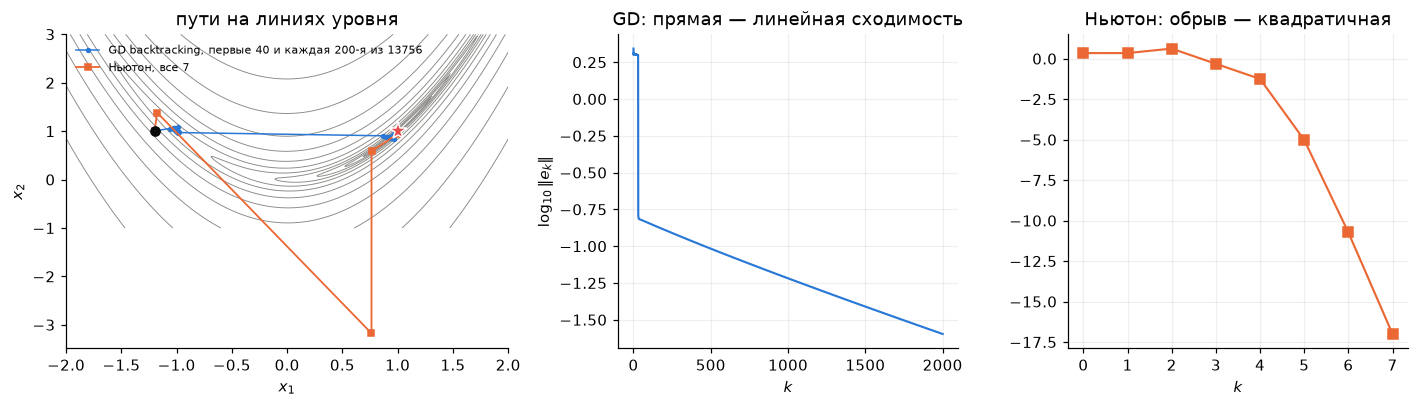

In [13]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.3, 1, 1]})
ax1.contour(X1_r := np.linspace(-2, 2, 400)[None, :] * np.ones((400, 1)), X2_r := np.linspace(-1, 3, 400)[:, None] * np.ones((1, 400)),
            (1 - X1_r)**2 + 100 * (X2_r - X1_r**2)**2, levels=np.logspace(-1, 3, 12), colors=[GRAY], linewidths=0.6)
gd_pts = np.r_[path_bt[:40], path_bt[40::200]]        # первые 40 точек целиком (спуск на дно), дальше каждая 200-я
ax1.plot(gd_pts[:, 0], gd_pts[:, 1], "-o", ms=2.5, lw=1, color=BLUE, label=f"GD backtracking, первые 40 и каждая 200-я из {k_bt}")
ax1.plot(path_n[:, 0], path_n[:, 1], "-s", ms=4, lw=1.2, color=ORANGE, label=f"Ньютон, все {k_n}")
ax1.plot(1, 1, "*", ms=12, color=RED, mec="white"); ax1.plot(-1.2, 1, "o", color=INK)
ax1.set(xlabel="$x_1$", ylabel="$x_2$", title="пути на линиях уровня"); ax1.legend(loc="upper left", fontsize=7.5); ax1.grid(False)

err_bt = np.linalg.norm(path_bt - 1, axis=1)
ax2.plot(np.arange(2001), np.log10(err_bt[:2001]), color=BLUE, lw=1.4)
ax2.set(xlabel="$k$", ylabel="$\\log_{10}\\|e_k\\|$", title="GD: прямая — линейная сходимость")
ax3.plot(np.arange(len(err_n)), np.log10(err_n + 1e-17), "-s", color=ORANGE, lw=1.4)
ax3.set(xlabel="$k$", title="Ньютон: обрыв — квадратичная", xticks=range(len(err_n)))
plt.tight_layout(); plt.show()

Сравните с оценкой из упражнения 12.4: множитель $1-1/\kappa$ при $\kappa=2508$ означает $\approx\kappa\ln10^6\approx3.5\cdot10^4$ итераций на уменьшение ошибки в $10^6$ раз — того же порядка, что 32 076 у шага $0.001$. Шаг $0.0019$ и backtracking (его шаг у дна долины $2^{-9}\approx0.00195$) вдвое быстрее, потому что ближе к границе $2/\lambda_{\max}$, — но остаются линейными, а за границей метод не сходится вовсе. Ньютону $\kappa$ безразлично: 7 итераций.

## (d) Логистическая регрессия и масштабирование признаков

Раздел 5 конспекта, упражнение 12.10. Данные из части (0). Градиент $\nabla f=\frac1nX^\top(\sigma(Xw)-y)$, гессиан $\nabla^2f=\frac1nX^\top SX$, $S=\operatorname{diag}(\sigma_i(1-\sigma_i))$ — выпукла. Гессиан — взвешенная матрица вторых моментов признаков, поэтому разброс признаков напрямую задаёт его спектр: возраст со std $10$ даёт собственное число в $100$ раз больше, чем стаж со std $1$, а столбец единиц и сдвиг средних добавляют ещё.

**Без стандартизации.** Минимум находим Ньютоном (должно быть 6 итераций) и считаем $\kappa$ гессиана в нём: ожидаем $\approx7.5\cdot10^4$. Градиентный спуск с backtracking за 20 000 итераций до $\|\nabla f\|\le10^{-6}$ дойти не должен — печатаем, что достиг.

In [14]:
sigmoid = lambda t: 1 / (1 + np.exp(-t))


def logistic(X, y):
    """Цель, градиент и гессиан логистической регрессии для матрицы признаков X и меток y из {0, 1}."""
    n = len(y)
    f = lambda w: np.mean(np.logaddexp(0, -(2 * y - 1) * (X @ w)))
    grad = lambda w: X.T @ (sigmoid(X @ w) - y) / n

    def hess(w):
        s = sigmoid(X @ w)
        return X.T @ (X * (s * (1 - s))[:, None]) / n

    return f, grad, hess


f_raw, grad_raw, hess_raw = logistic(X, y_cls)
w_raw, k_nraw, _ = newton(grad_raw, hess_raw, np.zeros(3))
lam = np.linalg.eigvalsh(hess_raw(w_raw))
print(f"Ньютон (исходные признаки): {k_nraw} итераций,  w* = {w_raw.round(4)}")
print(f"собственные числа гессиана в оптимуме: {lam},  κ = {lam[-1] / lam[0]:.3g}")

w_graw, k_graw, path_graw = gd(f_raw, grad_raw, np.zeros(3), maxit=20_000)
print(f"GD backtracking (исходные признаки): {k_graw} итераций, достигнуто |grad f| = {np.linalg.norm(grad_raw(w_graw)):.2e} (цель 1e-6),  |w_k - w*| = {np.linalg.norm(w_graw - w_raw):.3f}")

Ньютон (исходные признаки): 6 итераций,  w* = [-1.5517  0.1806 -1.0232]
собственные числа гессиана в оптимуме: [2.99396659e-03 1.56712701e-01 2.24729225e+02],  κ = 7.51e+04


GD backtracking (исходные признаки): 20000 итераций, достигнуто |grad f| = 4.60e-03 (цель 1e-6),  |w_k - w*| = 0.796


**Со стандартизацией.** Вычитаем среднее и делим на std каждого признака (столбец единиц не трогаем). Задача та же — только в других координатах: $w$ пересчитывается обратно линейно, предсказания совпадают. Ожидаем $\kappa\approx2.75$, GD — 195 итераций, Ньютон — 6.

In [15]:
mu, sd = X[:, 1:].mean(axis=0), X[:, 1:].std(axis=0)
Xs = np.c_[np.ones(n), (X[:, 1:] - mu) / sd]
f_std, grad_std, hess_std = logistic(Xs, y_cls)

w_std, k_nstd, _ = newton(grad_std, hess_std, np.zeros(3))
lam_s = np.linalg.eigvalsh(hess_std(w_std))
print(f"Ньютон (стандартизованные): {k_nstd} итераций,  w* = {w_std.round(4)},  κ = {lam_s[-1] / lam_s[0]:.3f}")
w_gstd, k_gstd, path_gstd = gd(f_std, grad_std, np.zeros(3), maxit=20_000)
print(f"GD backtracking (стандартизованные): {k_gstd} итераций, |grad f| = {np.linalg.norm(grad_std(w_gstd)):.1e}")

# обратно в исходные координаты: w0 + sum_j w_j (x_j - mu_j)/sd_j
w_back = np.r_[w_std[0] - np.sum(w_std[1:] * mu / sd), w_std[1:] / sd]
print(f"w* в исходных координатах: {w_back.round(4)}  (Ньютон на исходных дал {w_raw.round(4)}),  расхождение {np.linalg.norm(w_back - w_raw):.1e}")
acc = np.mean((X @ w_back > 0) == (y_cls == 1))
print(f"точность классификации на обучающих данных: {acc:.3f}")

Ньютон (стандартизованные): 6 итераций,  w* = [ 0.6228  1.8017 -1.0487],  κ = 2.749
GD backtracking (стандартизованные): 195 итераций, |grad f| = 1.0e-06
w* в исходных координатах: [-1.5517  0.1806 -1.0232]  (Ньютон на исходных дал [-1.5517  0.1806 -1.0232]),  расхождение 1.1e-15
точность классификации на обучающих данных: 0.815


**Картинка.** Слева — данные и разделяющая прямая $w^\top x=0$ в исходных координатах. Справа — $\|\nabla f(w_k)\|$ по итерациям для двух запусков GD: со стандартизацией норма градиента падает на 6 порядков за 195 итераций; без неё за 20 000 итераций — едва на 2.

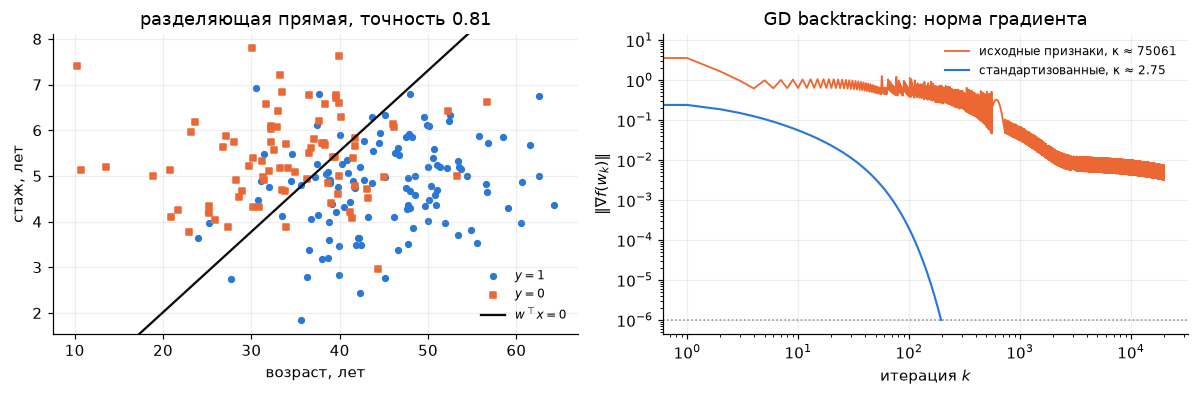

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.7))
ax1.scatter(age[y_cls == 1], exper[y_cls == 1], s=14, color=BLUE, label="$y=1$")
ax1.scatter(age[y_cls == 0], exper[y_cls == 0], s=14, color=ORANGE, marker="s", label="$y=0$")
aa = np.linspace(age.min(), age.max(), 2)
ax1.plot(aa, -(w_back[0] + w_back[1] * aa) / w_back[2], color=INK, lw=1.5, label="$w^\\top x=0$")
ax1.set(xlabel="возраст, лет", ylabel="стаж, лет", ylim=(exper.min() - 0.3, exper.max() + 0.3), title=f"разделяющая прямая, точность {acc:.2f}"); ax1.legend(fontsize=8)

gn_raw = np.linalg.norm(np.array([grad_raw(w) for w in path_graw]), axis=1)
gn_std = np.linalg.norm(np.array([grad_std(w) for w in path_gstd]), axis=1)
ax2.semilogy(gn_raw, color=ORANGE, lw=1.2, label=f"исходные признаки, κ ≈ {lam[-1] / lam[0]:.0f}")
ax2.semilogy(gn_std, color=BLUE, lw=1.4, label=f"стандартизованные, κ ≈ {lam_s[-1] / lam_s[0]:.2f}")
ax2.axhline(1e-6, color=GRAY, ls=":", lw=1)
ax2.set(xlabel="итерация $k$", ylabel="$\\|\\nabla f(w_k)\\|$", xscale="log", title="GD backtracking: норма градиента"); ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

Вывод: $\kappa$ здесь определяется не задачей, а **единицами измерения признаков** — сдвиг и масштаб столбцов матрицы $X$ меняют гессиан в $10^4$ раз, не меняя ни ответа, ни точности. Стандартизация признаков — первое лекарство, которое стоит применять до запуска любого градиентного метода (упражнение 12.5 — то же самое для метров и километров). Ньютону всё равно: 6 итераций в обоих случаях — он инвариантен к линейной замене переменных.

## (e) Цепь: $\kappa$ растёт с числом грузов

Раздел 5 конспекта, упражнение 12.9. Гессиан энергии — $\operatorname{diag}(DK,DK)$, поэтому $\kappa(\nabla^2E)=\kappa(K)$, а собственные числа $K$ известны: $2-2\cos\frac{j\pi}{N+1}$, откуда $\kappa\approx\big(\tfrac{2(N+1)}{\pi}\big)^2$. Проверяем таблицей для $N=10,20,40,80$: должны увидеть $48.4,\ 178.1,\ 680.6,\ 2658.4$ против формулы $49.0,\ 178.7,\ 681.3,\ 2659.1$ — $\kappa$ растёт как $N^2$. Чем мельче дробим цепь, тем хуже обусловлена задача.

In [17]:
print(" N   κ(K)      (2(N+1)/π)^2    λ_max(H)=L")
for N_ in (10, 20, 40, 80):
    _, _, _, K_, H_, _ = make_chain(N_)
    lamK = np.linalg.eigvalsh(K_)
    print(f"{N_:3d}  {lamK[-1] / lamK[0]:8.1f}   {(2 * (N_ + 1) / np.pi)**2:8.1f}        {D_CHAIN * lamK[-1]:.1f}")

 N   κ(K)      (2(N+1)/π)^2    λ_max(H)=L
 10      48.4       49.0        274.3
 20     178.1      178.7        278.4
 40     680.6      681.3        279.6
 80    2658.4     2659.1        279.9


**$N=40$: спуск против одного шага Ньютона.** Константа Липшица градиента $L=\lambda_{\max}(\nabla^2E)\approx279.6$, берём шаг $1/L$ и стартуем с прямой между концами. Ожидаем 10 575 итераций до $\|\nabla E\|\le10^{-6}$ и энергию $13.4417$. Функция квадратичная, поэтому квадратичная модель Ньютона точна и один шаг $-H^{-1}\nabla E$ из любой точки попадает в минимум — это ровно `np.linalg.solve(H, -grad(0))` из части (0); расхождение двух ответов должно быть на уровне допуска $10^{-6}$.

In [18]:
energy, grad_E, unpack, K, H, v0 = make_chain(40)
L = np.linalg.eigvalsh(H)[-1]
print(f"L = λ_max(H) = {L:.1f},  шаг 1/L = {1 / L:.5f}")
v_gd, k_gd, path_gd = gd(energy, grad_E, v0, alpha=1 / L)
print(f"GD с шагом 1/L: итераций {k_gd},  энергия {energy(v_gd):.4f},  |grad E| = {np.linalg.norm(grad_E(v_gd)):.1e}")
v_newton = v0 - np.linalg.solve(H, grad_E(v0))          # один шаг Ньютона из старта
print(f"один шаг Ньютона:  энергия {energy(v_newton):.4f},  |grad E| = {np.linalg.norm(grad_E(v_newton)):.1e}")
print(f"расхождение GD и Ньютона: max |Δv| = {np.abs(v_gd - v_newton).max():.1e},  |Δv| = {np.linalg.norm(v_gd - v_newton):.1e};  с решением из части (0): {np.linalg.norm(v_newton - v_chain):.1e}")

L = λ_max(H) = 279.6,  шаг 1/L = 0.00358


GD с шагом 1/L: итераций 10575,  энергия 13.4417,  |grad E| = 1.0e-06
один шаг Ньютона:  энергия 13.4417,  |grad E| = 1.5e-13
расхождение GD и Ньютона: max |Δv| = 5.4e-07,  |Δv| = 2.4e-06;  с решением из части (0): 3.0e-14


**Число итераций от $N$.** Тот же спуск с шагом $1/L$ для $N=10,20,40,80$ (`maxit=60_000`). Ожидаем рост $\propto\kappa\propto N^2$: удвоение числа грузов — вчетверо больше итераций. Пунктир — $k_{40}\cdot\kappa(N)/\kappa(40)$.

N = 10: κ =    48.4,  итераций GD: 779
N = 20: κ =   178.1,  итераций GD: 2825


N = 40: κ =   680.6,  итераций GD: 10575


N = 80: κ =  2658.4,  итераций GD: 40388


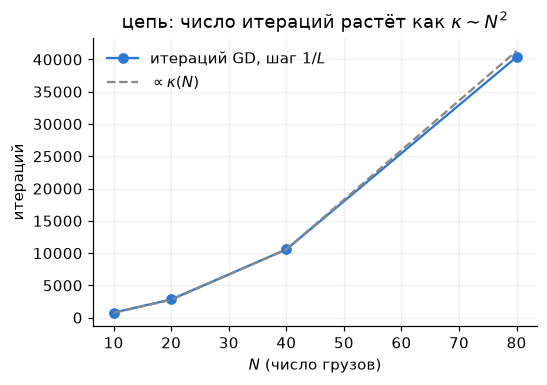

In [19]:
Ns, iters, kappas = (10, 20, 40, 80), [], []
for N_ in Ns:
    e_, g_, _, K_, H_, v0_ = make_chain(N_)
    lamK = np.linalg.eigvalsh(K_); kappas.append(lamK[-1] / lamK[0])
    _, k_, _ = gd(e_, g_, v0_, alpha=1 / (D_CHAIN * lamK[-1]), maxit=60_000)
    iters.append(k_)
    print(f"N = {N_:2d}: κ = {kappas[-1]:7.1f},  итераций GD: {k_}" + ("  (упёрлись в maxit)" if k_ >= 60_000 else ""))
kappas, iters = np.array(kappas), np.array(iters)

plt.figure(figsize=(5.2, 3.4))
plt.plot(Ns, iters, "o-", color=BLUE, label="итераций GD, шаг $1/L$")
plt.plot(Ns, iters[2] * kappas / kappas[2], "--", color=GRAY, label="$\\propto\\kappa(N)$")
plt.xlabel("$N$ (число грузов)"); plt.ylabel("итераций"); plt.legend(); plt.title("цепь: число итераций растёт как $\\kappa\\sim N^2$")
plt.show()

Один и тот же метод, одна и та же физика — и в четыре раза больше итераций на каждое удвоение $N$: число обусловленности растёт с размерностью, а вместе с ним и цена градиентного спуска. Ньютон (здесь — одна линейная система) от $N$ так не зависит. Что делать, когда гессиан считать дорого или он не положительно определён, — лекция 5.

## Шпаргалка

| Что | Формула | Где в конспекте |
|---|---|---|
| условие первого порядка (необходимое) | $x^\ast$ — локальный минимум $\Rightarrow\nabla f(x^\ast)=0$ (стационарная точка) | раздел 2 |
| условия второго порядка | необходимое: $\nabla^2f(x^\ast)\succeq0$; достаточное: $\nabla f=0$ и $\nabla^2f\succ0$ $\Rightarrow$ строгий локальный минимум; между ними зазор ($x^4$, $x^3$, $-x^4$) | раздел 3 |
| классификация по гессиану | все $\lambda_i>0$ — минимум; все $<0$ — максимум; разных знаков — седло | раздел 3, часть (a) |
| лемма о спуске | $\|\nabla f(x)-\nabla f(y)\|\le L\|x-y\|$ $\Rightarrow$ $f(x-\alpha\nabla f)\le f-\alpha\big(1-\tfrac{\alpha L}2\big)\|\nabla f\|^2$; убывает при $0<\alpha<2/L$, лучший гарантированный шаг $1/L$; для квадратичной $L=\lambda_{\max}(Q)$ | раздел 4, 12.6 |
| точный шаг на квадратичной | $\alpha_k=\dfrac{g_k^\top g_k}{g_k^\top Qg_k}$, $\nabla f(x_{k+1})\perp\nabla f(x_k)$ — зигзаг | раздел 4, часть (b) |
| множители сжатия | шаг $1/L$: $\|e_{k+1}\|\le(1-1/\kappa)\|e_k\|$; точный шаг: $f_{k+1}\le\big(\tfrac{\kappa-1}{\kappa+1}\big)^2f_k$; лучший постоянный шаг $2/(\lambda_{\max}+\lambda_{\min})$: $\tfrac{\kappa-1}{\kappa+1}$ | раздел 5 |
| цена в итерациях | на одну верную цифру $\approx\ln10/(-\ln(1-1/\kappa))\approx2.3\,\kappa$ при шаге $1/L$ | раздел 5 |
| число обусловленности | $\kappa=\lambda_{\max}(\nabla^2f(x^\ast))/\lambda_{\min}(\nabla^2f(x^\ast))$; зависит от масштаба переменных — стандартизируйте | раздел 5, части (d)–(e) |
| линейная сходимость | $\|e_{k+1}\|\le q\|e_k\|$, $q<1$: на графике $\log\|e_k\|$ — прямая | раздел 6 |
| сверхлинейная | $\|e_{k+1}\|/\|e_k\|\to0$ | раздел 6 |
| квадратичная | $\|e_{k+1}\|\le C\|e_k\|^2$: число верных цифр удваивается | раздел 6, часть (c) |
| шаг Ньютона | $x_{k+1}=x_k-\nabla^2f(x_k)^{-1}\nabla f(x_k)$: минимум квадратичной модели; на квадратичной $f$ — один шаг = `np.linalg.solve` | раздел 7, части (c), (e) |

Три вещи, которые легко перепутать:

1. **Стационарная точка $\ne$ минимум.** Градиентный спуск останавливается там, где $\nabla f=0$; седло $(0,0)$ из части (a) проходит этот тест. Смотрите на собственные числа гессиана.
2. **Шаг $\alpha$ и константа $L$ — в одних единицах.** Лемма о спуске говорит $\alpha<2/L$, а $L$ — самое большое собственное число гессиана; для Розенброка $2/L\approx0.002$, для цепи с $N=40$ — $\approx0.007$, а в логистической регрессии без стандартизации ещё в сотни раз меньше. Шаг «$0.01$ по умолчанию» ничем не обоснован.
3. **Ньютон не «всегда быстрее».** Квадратичная сходимость — только вблизи минимума; из $(-1.2,1)$ второй шаг Розенброка увеличил ошибку. Что с этим делать — лекция 5.